# NO₂ Forecasting Project Report

This notebook documents the full workflow used to preprocess atmospheric NO₂ observations, engineer temporal features, explore the spatial structure of the data, and train multiple forecasting models.

The notebook is organized into the following stages:

1. Data loading and inspection  
2. Data preprocessing and temporal feature engineering  
3. Spatial visualization and exploratory analysis  
4. Baseline forecasting models  
5. XGBoost
6. Deep learning approaches for spatiotemporal prediction  

The code has been reorganized so that the notebook can be read as a project report when code cells are hidden.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Project Configuration

The following configuration cell defines the project directories used throughout the notebook.

- `./data/interim/` stores transformed and intermediate datasets.
- `./models/` stores trained model checkpoints and serialized models.

Creating the directories at the start of the notebook keeps the workflow reproducible and prevents file path issues later in the pipeline.


# Project Roadmap

This notebook follows the complete workflow used to forecast NO₂ concentration fields from sparse atmospheric observations.

The major stages are:

1. **Data preprocessing**
   - Clean timestamps and coordinates
   - Align meteorological variables
   - Construct lagged temporal features

2. **Spatial analysis**
   - Visualize station distributions
   - Understand sparsity and spatial coverage

3. **Baseline modeling**
   - Persistence baseline
   - Quantify how predictable NO₂ already is without ML

4. **Tree-based modeling**
   - XGBoost regression on engineered features
   - Analyze feature importance and prediction quality

5. **Spatial regularization**
   - Convert sparse observations into dense regular grids
   - Prepare image-like tensors for deep learning

6. **Deep learning approaches**
   - CNN forecasting
   - ConvLSTM forecasting
   - UNet encoder-decoder forecasting

7. **Evaluation**
   - Compare models
   - Visualize predictions on selected dates
   - Analyze strengths and limitations



## Persistence Baseline

Before training machine learning models, it is important to establish a simple baseline forecast.

The persistence baseline assumes:

$\hat{y}_{t+1} = y_t$

This is a surprisingly strong benchmark for atmospheric forecasting because air pollution evolves gradually over time.

Why this baseline matters:
- It provides a minimum performance threshold.
- It tells us whether complex models are actually learning meaningful dynamics.
- If advanced models cannot outperform persistence, then the added complexity is not justified.

The persistence model is especially useful for short-term forecasting where temporal autocorrelation is high.



## Gradient Boosting with XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm based on decision trees.

Instead of training a single model, XGBoost builds many small regression trees sequentially. Each new tree attempts to correct the errors made by the previous trees.

Advantages of XGBoost for this task:
- Handles nonlinear relationships effectively
- Works well with tabular data
- Captures interactions between weather, location, and temporal features
- Robust to missing values
- Computationally efficient

Input features include:
- latitude and longitude,
- temperature,
- lagged NO₂ values from previous days.

The model predicts the NO₂ concentration for the next day.



## Why Spatial Reprojection / Regularization Was Necessary

The original NO₂ observations are collected at irregularly spaced locations.

This creates two major problems for spatial forecasting models:

1. **Convolutional neural networks assume regular grids**
   CNNs operate using fixed-size kernels over neighboring pixels. Sparse station coordinates do not satisfy this assumption because neighboring observations are unevenly spaced.

2. **Spatial relationships become difficult to learn**
   Distances between stations vary significantly, making local spatial patterns inconsistent.

To address this, the sparse station observations are projected onto a regular latitude-longitude grid using radius-based interpolation.

This process:
- converts point observations into image-like tensors,
- preserves approximate spatial structure,
- enables convolution operations,
- and allows temporal stacks of NO₂ maps to be processed efficiently by deep learning models.

The tradeoff is that interpolation smooths some local spatial detail and may introduce artifacts in regions with limited observations.



## Why Move Beyond XGBoost?

While XGBoost performs well on tabular forecasting tasks, it has important limitations for spatial atmospheric modeling.

The model treats each observation independently and does not explicitly learn:
- spatial continuity,
- neighborhood structure,
- transport patterns,
- or evolving spatial fields.

As a result:
- fine spatial interactions may be lost,
- local pollution diffusion patterns are not modeled directly,
- and reconstructed maps can appear spatially fragmented.

Deep learning approaches such as CNNs and ConvLSTMs are designed specifically for structured spatial-temporal data.

By converting NO₂ observations into image-like grids, these models can learn:
- local spatial correlations,
- temporal evolution,
- and large-scale spatial patterns simultaneously.



## Evaluation Metrics

The forecasting models are evaluated using multiple complementary metrics.

### Mean Absolute Error (MAE)

$MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$

Lower values indicate better predictions.

### Root Mean Squared Error (RMSE)


$RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$


Penalizes larger forecasting errors more strongly.

### R² Score

$R^2=1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$

Higher values indicate stronger predictive performance.


In [2]:

def visualize_predictions_for_dates(
    dates,
    model,
    feature_cols,
    dataframe,
    lat_col="latitude",
    lon_col="longitude",
    target_col="no2_day0"
):
    import matplotlib.pyplot as plt
    import pandas as pd

    for selected_date in dates:

        day_df = dataframe[dataframe["datetime"] == pd.to_datetime(selected_date)].copy()

        X_day = day_df[feature_cols]
        preds = model.predict(X_day)

        day_df["prediction"] = preds

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        sc1 = axes[0].scatter(
            day_df[lon_col],
            day_df[lat_col],
            c=day_df[target_col],
            s=40
        )
        axes[0].set_title(f"Actual NO₂ ({selected_date})")
        plt.colorbar(sc1, ax=axes[0])

        sc2 = axes[1].scatter(
            day_df[lon_col],
            day_df[lat_col],
            c=day_df["prediction"],
            s=40
        )
        axes[1].set_title(f"Predicted NO₂ ({selected_date})")
        plt.colorbar(sc2, ax=axes[1])

        plt.tight_layout()
        plt.show()

dates_to_evaluate = [
    "2019-02-01",
    "2019-04-15",
    "2019-07-10"
]

# Example call:
# visualize_predictions_for_dates(
#     dates_to_evaluate,
#     xgb_model,
#     feature_cols,
#     no2_lagged_df
# )


In [3]:
INTERIM_DATA_DIR = "./data/interim"
MODEL_DIR = "./models"

os.makedirs(INTERIM_DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


In [4]:
no2 = pd.read_csv("./data/NO2_manual_1213m.csv")
wind_u = pd.read_csv("./data/WIND_U_manual_27929m.csv")
# wind_v = pd.read_csv("./data/WIND_V_manual_27929m.csv")
temp = pd.read_csv("./data/TEMP_manual_27929m.csv")
co = pd.read_csv("./data/CO_manual_1213m.csv")



# What do these things do?

In [5]:
def _get_station_grid_lookup(weather_df):
    cache_key = "_station_grid_lookup"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    station_latitudes = np.sort(weather_df["latitude"].dropna().unique())
    station_longitudes = np.sort(weather_df["longitude"].dropna().unique())

    if len(station_latitudes) == 0 or len(station_longitudes) == 0:
        raise ValueError("weather_df must contain at least one valid latitude and longitude.")

    lat_bounds = np.concatenate(([-np.inf], (station_latitudes[:-1] + station_latitudes[1:]) / 2, [np.inf]))
    lon_bounds = np.concatenate(([-np.inf], (station_longitudes[:-1] + station_longitudes[1:]) / 2, [np.inf]))

    cached = (station_latitudes, station_longitudes, lat_bounds, lon_bounds)
    weather_df.attrs[cache_key] = cached
    return cached


def _nearest_station_coordinate(value, station_values, bounds):
    station_index = np.searchsorted(bounds, value, side="right") - 1
    station_index = int(np.clip(station_index, 0, len(station_values) - 1))
    return station_values[station_index]


def _get_daily_station_cache(weather_df, col):
    cache_key = f"_daily_station_cache::{col}"
    cached = weather_df.attrs.get(cache_key)
    if cached is not None:
        return cached

    timestamps = weather_df.attrs.get("_timestamp_cache")
    if timestamps is None or len(timestamps) != len(weather_df):
        timestamps = pd.to_datetime(weather_df["timestamp"], errors="coerce")
        weather_df.attrs["_timestamp_cache"] = timestamps

    valid_rows = timestamps.notna() & weather_df[col].notna() & weather_df["latitude"].notna() & weather_df["longitude"].notna()
    daily_station_cache = {}

    if valid_rows.any():
        day_values = timestamps.loc[valid_rows].dt.normalize()
        valid_frame = weather_df.loc[valid_rows, ["latitude", "longitude", col]].copy()
        valid_frame["day"] = day_values.values
        grouped = (
            valid_frame.groupby(["day", "latitude", "longitude"], as_index=False)[col]
            .mean()
        )

        for day, day_frame in grouped.groupby("day", sort=False):
            daily_station_cache[pd.Timestamp(day)] = day_frame.set_index(["latitude", "longitude"])[col].to_dict()

    weather_df.attrs[cache_key] = daily_station_cache
    return daily_station_cache


def get_avg_weather_for_closest_latlong(latitude, longitude, date, weather_df, col):
    date = pd.to_datetime(date)
    day_start = date.normalize()

    if "timestamp" not in weather_df.columns:
        raise KeyError("weather_df must contain a 'timestamp' column.")
    if col not in weather_df.columns:
        raise KeyError(f"{col} not found in weather_df columns.")

    station_latitudes, station_longitudes, lat_bounds, lon_bounds = _get_station_grid_lookup(weather_df)
    closest_latitude = _nearest_station_coordinate(latitude, station_latitudes, lat_bounds)
    closest_longitude = _nearest_station_coordinate(longitude, station_longitudes, lon_bounds)

    daily_station_cache = _get_daily_station_cache(weather_df, col)
    day_values = daily_station_cache.get(day_start)

    if day_values is None:
        raise ValueError(f"No weather data found for date {day_start.date()}.")

    station_value = day_values.get((closest_latitude, closest_longitude))
    if station_value is not None and not pd.isna(station_value):
        return station_value

    day_mask = pd.to_datetime(weather_df["timestamp"], errors="coerce").dt.normalize().eq(day_start)
    daily_weather = weather_df.loc[day_mask, ["latitude", "longitude", col]].dropna(subset=[col])
    if daily_weather.empty:
        raise ValueError(f"No usable weather values found for date {day_start.date()}.")

    distance = (daily_weather[["latitude", "longitude"]] - [latitude, longitude]).abs().sum(axis=1)
    closest_idx = distance.idxmin()
    return daily_weather.loc[closest_idx, col]


wind_u["timestamp"] = pd.to_datetime(wind_u["timestamp"], errors="coerce")
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
# 28.219475044486515,77.1511982864422,192.0,2019-01-09
print(get_avg_weather_for_closest_latlong(29.219475044486515, 79.2011985864423, "2019-01-09", temp, "TEMP"))


286.45952916666664


Below is the code I used to visualize how the temperature stations are located across my ROI, and what latlongs i have no2 data for (from a random days image)(also shows missingness on that day, but that is an aside)
 - Why NO2_lagged? What it mean?

## Exploratory Spatial Analysis

This section visualizes the spatial distribution of monitoring stations and NO₂ concentrations across the region of interest. These plots help validate coverage and identify spatial sparsity before modeling.

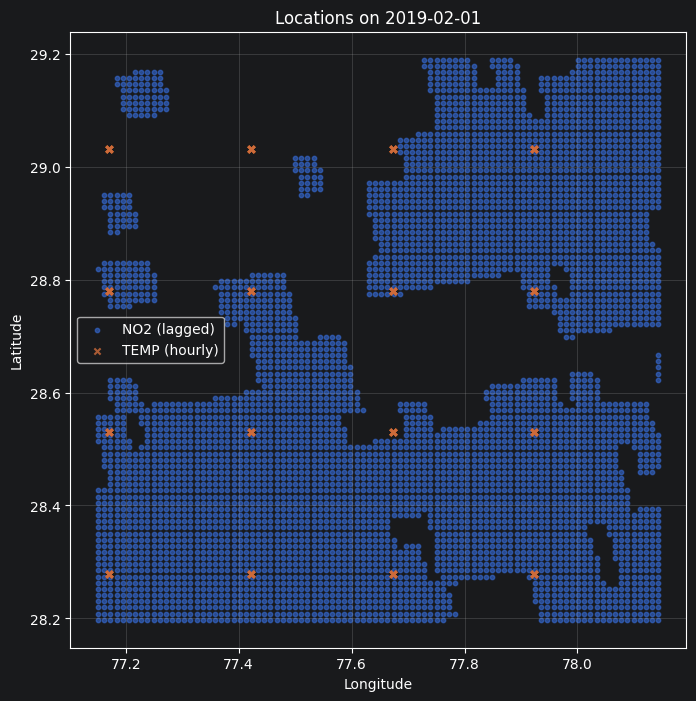

In [6]:
# plot lat/lon points from no2_lagged_df and temp for a single day
selected_day = pd.to_datetime("2019-02-01").normalize()

# ensure temp timestamps are datetimes
temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="coerce")
temp_day = temp[temp["timestamp"].dt.normalize() == selected_day]

no2_day = no2[pd.to_datetime(no2["timestamp"]).dt.normalize() == selected_day]

plt.figure(figsize=(8, 8))
plt.scatter(no2_day["longitude"], no2_day["latitude"], s=10, c="C0", alpha=0.6, label="NO2 (lagged)")
plt.scatter(temp_day["longitude"], temp_day["latitude"], s=20, c="C1", marker="x", alpha=0.8, label="TEMP (hourly)")
plt.title(f"Locations on {selected_day.date()}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.3)
plt.show()

# Section 1: Data preprocessing 

first we establish the lagged dataset, which involves creating new features based on previous time steps of the data. For example, if we have a time series, we can create lagged features such as the n02 at time t-1, t-2, etc. This hopefully will allow us to capture the temporal dependencies in the data.

Now we create the lagged dataset. The preprocessing stage adds NO₂ observations from the previous seven days together with weather-related variables that can help the models capture temporal structure. values of current day as features to predict the no2 value of the next day.

## Lagged Feature Engineering

Temporal forecasting models benefit from historical context. The next cells create lagged NO₂ features so that each row contains information from previous days for the same spatial location.

In [7]:
# adding nearest temp reading to the dataset
from tqdm.auto import tqdm



date_column = "timestamp"

no2[date_column] = pd.to_datetime(no2[date_column], errors="coerce")
no2 = no2.dropna(subset=[date_column]).copy()
no2["day"] = no2[date_column].dt.normalize()

value_column = "NO2"
# Compute TEMP once per unique (latitude, longitude, day) and merge it back into no2.
unique_day_locs = no2[["latitude", "longitude", "day"]].drop_duplicates().reset_index(drop=True)

temps = []
for lat, lon, day in tqdm(
    unique_day_locs.itertuples(index=False, name=None),
    total=len(unique_day_locs),
    desc="Computing TEMP for unique (lat,lon,day)",
):
    try:
        val = get_avg_weather_for_closest_latlong(lat, lon, day, temp, "TEMP")
    except Exception:
        val = np.nan
    temps.append(val)

unique_day_locs["TEMP"] = temps
no2 = no2.merge(unique_day_locs, on=["latitude", "longitude", "day"], how="left")

print(f"Attached TEMP to no2 for {len(unique_day_locs)} unique (lat, lon, day) rows.")
no2[["latitude", "longitude", "day", "TEMP"]].head()

/home/arjun/Shared_Drive/ClimateProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Computing TEMP for unique (lat,lon,day): 100%|██████████| 2056978/2056978 [00:30<00:00, 67090.11it/s]


Attached TEMP to no2 for 2056978 unique (lat, lon, day) rows.


,latitude,longitude,day,TEMP
0,28.197678,77.151198,2019-01-01,287.244276
1,28.197678,77.162097,2019-01-01,287.244276
2,28.197678,77.172995,2019-01-01,287.244276
3,28.197678,77.183893,2019-01-01,287.244276
4,28.197678,77.194792,2019-01-01,287.244276


In [8]:
daily_no2 = (
    no2.groupby(["latitude", "longitude", "timestamp"], as_index=False)
    .agg(
        no2=("NO2", "mean"),
        TEMP=("TEMP", "mean"),
    )
)

if "elevation" in no2.columns:
    elevation_by_location = (
        no2[["latitude", "longitude", "elevation"]]
        .dropna(subset=["latitude", "longitude"])
        .drop_duplicates(subset=["latitude", "longitude"])
    )
    daily_no2 = daily_no2.merge(elevation_by_location, on=["latitude", "longitude"], how="left")
else:
    daily_no2["elevation"] = np.nan

daily_no2 = daily_no2.sort_values(["latitude", "longitude", "timestamp"]).reset_index(drop=True)

lag_columns = []
for lag in range(0, 8):
    column_name = f"no2_day{lag}"
    daily_no2[column_name] = daily_no2.groupby(["latitude", "longitude"])["no2"].shift(lag)
    lag_columns.append(column_name)

no2_lagged_df = daily_no2.rename(columns={"timestamp": "datetime"})[
    ["latitude", "longitude", "elevation", "datetime", "TEMP"] + lag_columns
].dropna(subset=lag_columns).reset_index(drop=True)

print(f"Created lagged NO2 dataset with shape: {no2_lagged_df.shape}")
no2_lagged_df.head()

Created lagged NO2 dataset with shape: (1842537, 13)


,latitude,longitude,elevation,datetime,TEMP,no2_day0,no2_day1,no2_day2,no2_day3,no2_day4,no2_day5,no2_day6,no2_day7
0,28.197678,77.151198,NaN,2019-01-09 07:54:00,286.470429,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057,0.000042,0.000102
1,28.197678,77.151198,NaN,2019-01-10 07:35:00,287.288570,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057,0.000042
2,28.197678,77.151198,NaN,2019-01-11 07:16:00,287.253496,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052,0.000057
3,28.197678,77.151198,NaN,2019-01-12 06:57:00,287.051488,0.000033,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048,0.000052
4,28.197678,77.151198,NaN,2019-01-14 08:01:00,286.025774,0.000071,0.000033,0.000086,0.000076,0.000062,0.000057,0.000073,0.000048


In [9]:
no2_lagged_df = no2_lagged_df.sort_values(["datetime", "latitude", "longitude"]).reset_index(drop=True)


In [10]:
no2_lagged_df.to_csv("/home/arjun/Shared_Drive/ClimateProject/haha/data/no2_lagged.csv", index=False)

below is code to visualise monthly heatmaps of the no2 data

In [11]:
def monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-02-01")):
    # Validate column
    if plot_col not in no2_lagged_df.columns:
        raise KeyError(f"{plot_col} not found in no2_lagged_df columns.")

    # Ensure datetime is normalized (date-only) for reliable filtering
    no2_lagged_df["datetime"] = pd.to_datetime(no2_lagged_df["datetime"]).dt.normalize()

    # If selected date is outside available range, snap to nearest available date
    available_dates = no2_lagged_df["datetime"].dropna().sort_values().unique()
    if len(available_dates) == 0:
        raise ValueError("no2_lagged_df has no valid datetime values.")

    nearest_datetime = min(available_dates, key=lambda d: abs(d - selected_datetime.to_datetime64()))
    nearest_datetime = pd.to_datetime(nearest_datetime)

    # Build month window from nearest date (fixes empty month issue like 2020-01 for 2019-only data)
    month_start = nearest_datetime.to_period("M").to_timestamp()
    month_end = month_start + pd.offsets.MonthEnd(1)
    all_days = pd.date_range(month_start, month_end, freq="D")

    # Data for this month
    month_df = no2_lagged_df[
        (no2_lagged_df["datetime"] >= month_start) &
        (no2_lagged_df["datetime"] <= month_end)
    ].copy()

    if month_df.empty:
        raise ValueError(f"No data found for month {month_start.strftime('%Y-%m')}.")

    # Shared color scale
    vmin = month_df[plot_col].min()
    vmax = month_df[plot_col].max()
    if pd.isna(vmin) or pd.isna(vmax):
        raise ValueError(f"{plot_col} is all-NaN in {month_start.strftime('%Y-%m')}.")

    # Grid layout
    n_days = len(all_days)
    ncols = 7
    nrows = int(np.ceil(n_days / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    last_mesh = None

    for i, day in enumerate(all_days):
        ax = axes[i]
        day_df = month_df[month_df["datetime"] == day]

        if day_df.empty:
            ax.set_title(f"{day.date()}\n(no data)", fontsize=9)
            ax.axis("off")
            continue

        heatmap_df = day_df.pivot_table(
            index="latitude",
            columns="longitude",
            values=plot_col,
            aggfunc="mean"
        ).sort_index().sort_index(axis=1)

        if heatmap_df.empty or np.all(np.isnan(heatmap_df.values)):
            ax.set_title(f"{day.date()}\n(no valid values)", fontsize=9)
            ax.axis("off")
            continue

        lon_grid, lat_grid = np.meshgrid(heatmap_df.columns.values, heatmap_df.index.values)
        last_mesh = ax.pcolormesh(
            lon_grid, lat_grid, heatmap_df.values,
            shading="auto", cmap="viridis", vmin=vmin, vmax=vmax
        )

        ax.set_title(str(day.date()), fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    # Hide extra axes
    for j in range(n_days, len(axes)):
        axes[j].axis("off")

    # Shared colorbar
    if last_mesh is not None:
        fig.colorbar(last_mesh, ax=axes.tolist(), shrink=0.85, label=plot_col)

    fig.suptitle(f"Daily {plot_col} Heatmaps - {month_start.strftime('%B %Y')}", fontsize=14)
    plt.show()


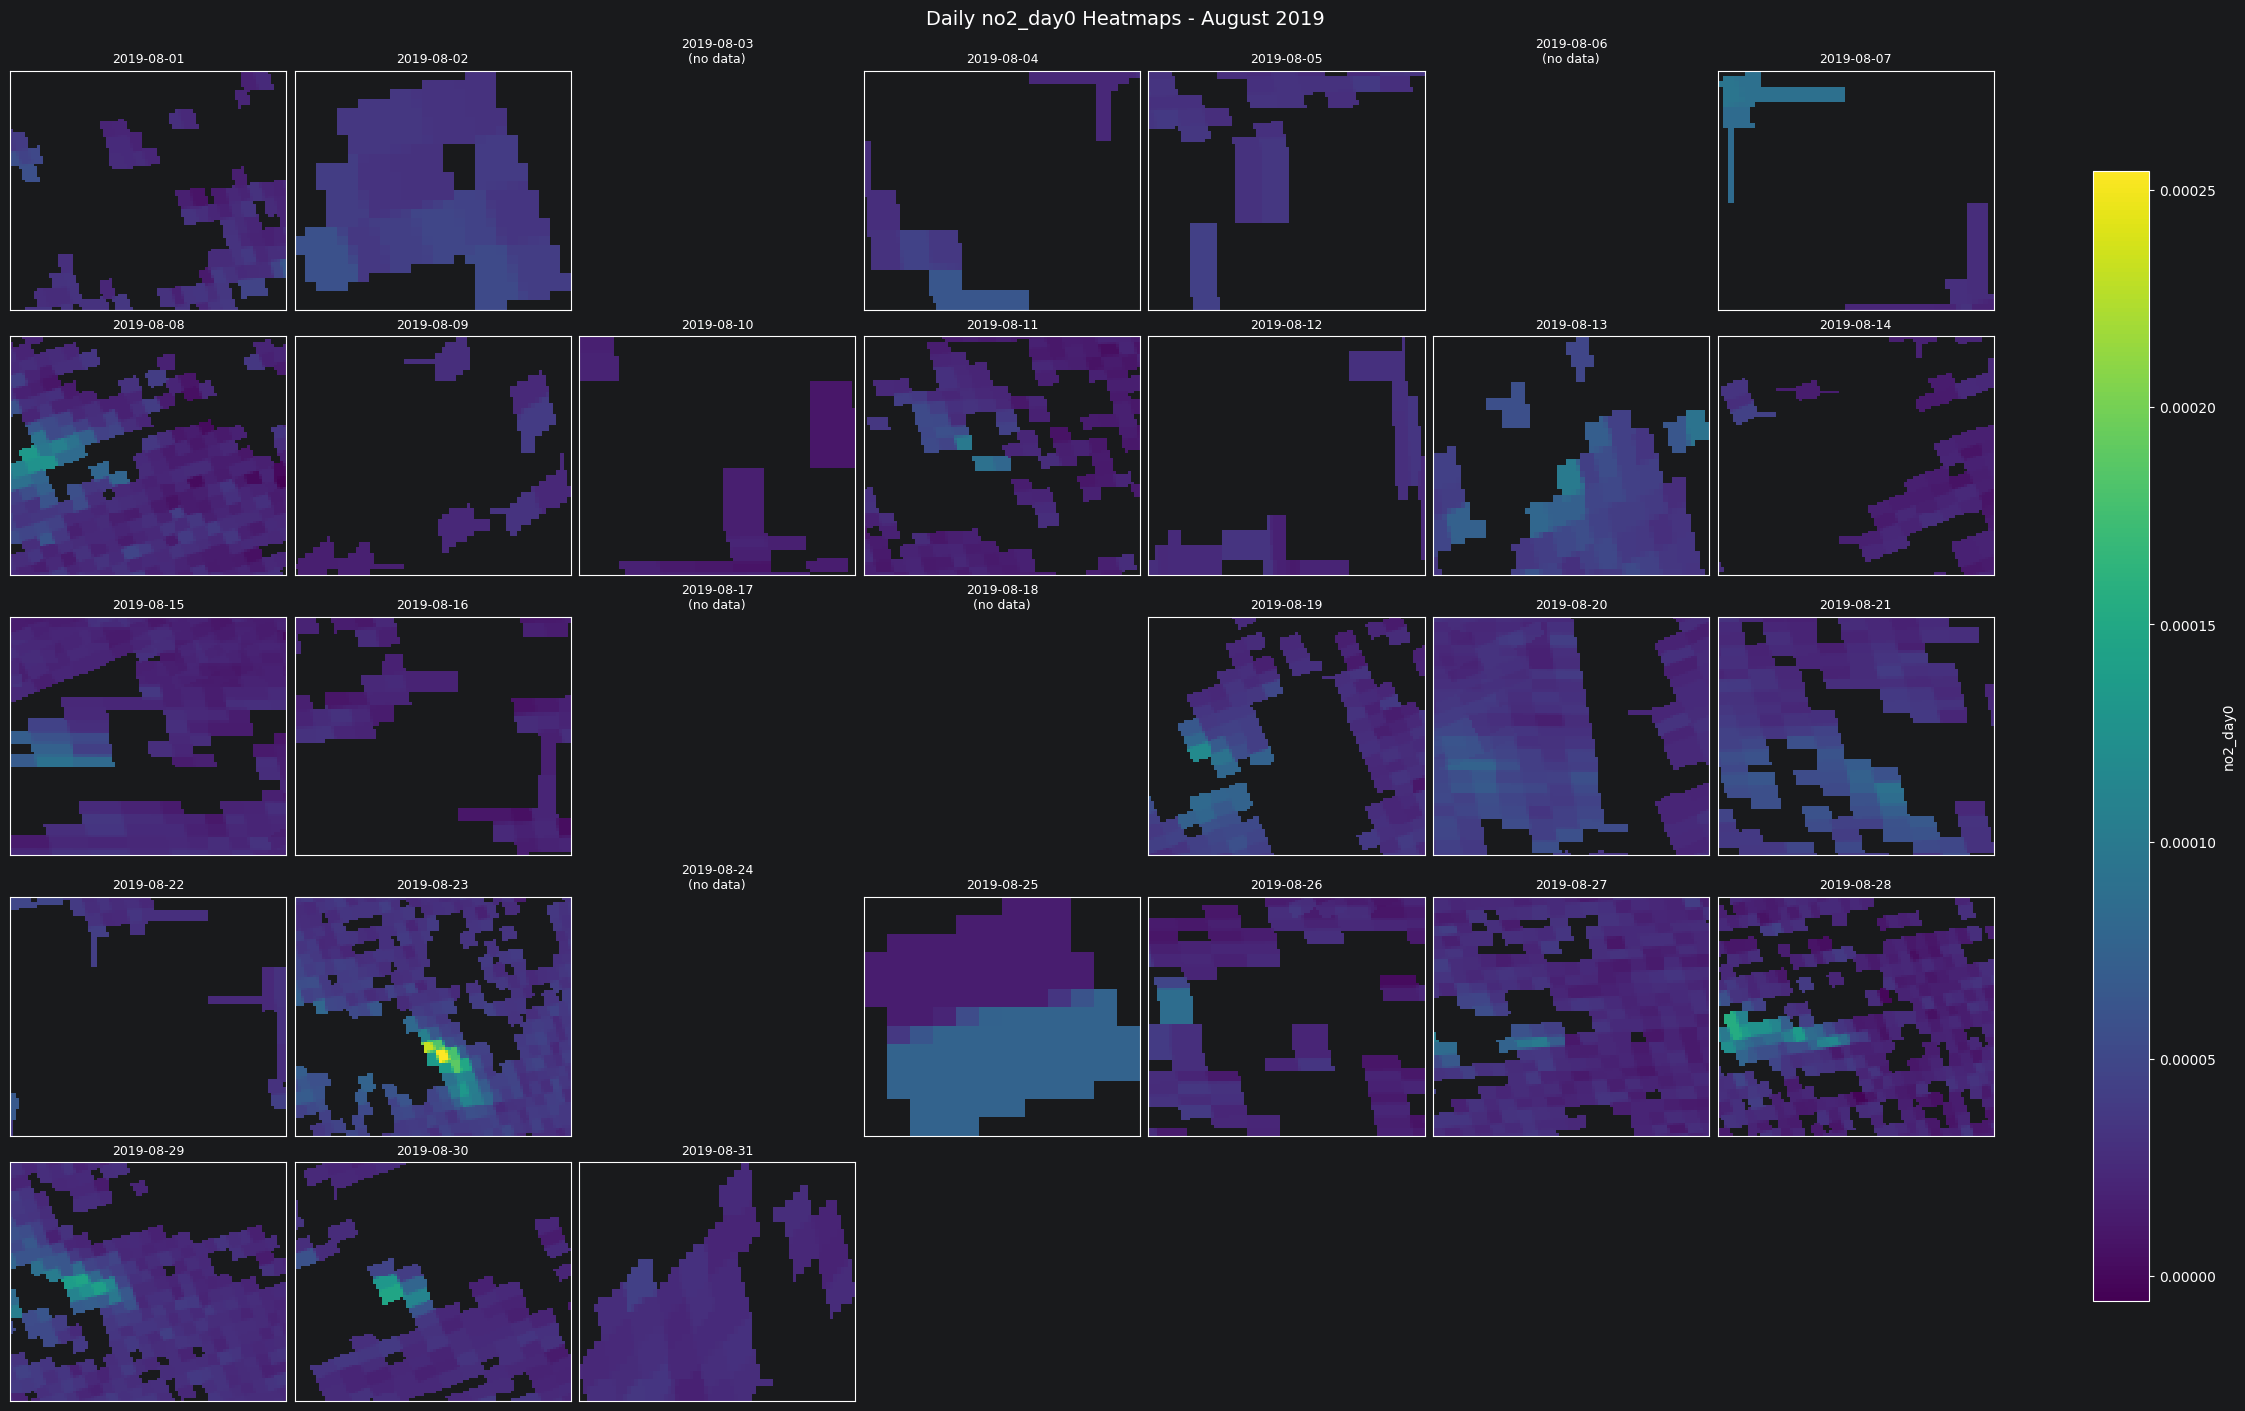

In [37]:
monthly_heatmaps(no2_lagged_df=no2_lagged_df, plot_col="no2_day0", selected_datetime=pd.to_datetime("2019-08-01"))

Checklist for next steps:
* ~~Build daily 2D grids from the tuples~~
* ~~Use last 7 days to predict next day~~
* Try:
    - ~~persistence baseline~~
    - ~~XGBoost on lagged features~~
    - Deep learning models:
        - CNN 
        - ConvLSTM 
        - Unet encoder-decoder
        - 3D CNN
* ~~Add mask + time features~~
* graph models if needed

# persistence baseline

## Persistence Baseline

Before training complex models, a simple persistence baseline is evaluated. This baseline assumes that today's NO₂ concentration is similar to yesterday's value. It provides a reference point for judging whether more advanced models actually improve forecasting performance.

Persistence baseline for NO2
Train rows: 1,464,930
Test rows:  377,607
Time split:  2019-10-24 to 2019-12-31
MAE:  0.0000
RMSE: 0.0001
R^2:  0.1506
NMAE: 0.4532


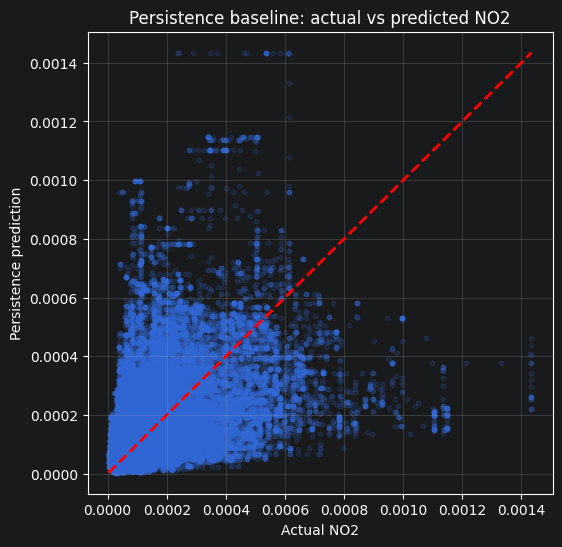

In [13]:
# Persistence baseline for NO2
# Idea: for each pixel-day, predict today's NO2 using yesterday's NO2.
# This is a strong sanity-check baseline before trying any neural network.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Choose the target and the persistence feature.
# In this lagged table:
# - no2_day0 = today's NO2 (the thing we want to predict)
# - no2_day1 = yesterday's NO2 (the persistence forecast)
target_col = "no2_day0"
pred_col = "no2_day1"

# 2) Keep only rows where both target and persistence input exist.
baseline_df = no2_lagged_df[["datetime", "latitude", "longitude", target_col, pred_col]].dropna().copy()
baseline_df = baseline_df.sort_values("datetime").reset_index(drop=True)

# 3) Make a time-based split so we evaluate on future dates, not shuffled rows.
unique_dates = baseline_df["datetime"].drop_duplicates().sort_values().to_list()
cutoff_index = max(1, int(len(unique_dates) * 0.8))
train_dates = set(unique_dates[:cutoff_index])
test_dates = set(unique_dates[cutoff_index:])

train_df = baseline_df[baseline_df["datetime"].isin(train_dates)].copy()
test_df = baseline_df[baseline_df["datetime"].isin(test_dates)].copy()

# 4) Evaluate the baseline on the held-out future period.
y_true = test_df[target_col].to_numpy()
y_pred = test_df[pred_col].to_numpy()

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# A simple normalized error helps when NO2 values vary a lot across pixels.
mean_abs_target = np.mean(np.abs(y_true))
nmae = mae / mean_abs_target if mean_abs_target != 0 else np.nan

print("Persistence baseline for NO2")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows:  {len(test_df):,}")
print(f"Time split:  {min(test_df['datetime']).date()} to {max(test_df['datetime']).date()}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")
print(f"NMAE: {nmae:.4f}")

# # 5) Save predictions so you can inspect where persistence works well or fails.
# baseline_predictions = test_df[["datetime", "latitude", "longitude", target_col, pred_col]].rename(
#     columns={target_col: "no2_true", pred_col: "no2_persistence_pred"}
# )

# 6) Quick diagnostic plot: actual vs predicted.
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.15, s=10)
min_val = min(np.min(y_true), np.min(y_pred))
max_val = max(np.max(y_true), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
plt.xlabel("Actual NO2")
plt.ylabel("Persistence prediction")
plt.title("Persistence baseline: actual vs predicted NO2")
plt.grid(True, alpha=0.3)
plt.show()

# baseline_predictions.head()

# XGBoost 

We will use latitude, longitude, temperature, and the seven lagged NO₂ values as predictive features. as features to predict `no2_day0`. The `datetime` column is only used to keep the train/test split chronological.

## What all are we doing?
- What losses are we using? What looks better, why?
- What are the hyperparams? Which ones work good?
- How much lead time is significant? By how much?
- Label the plot, x-axis is \#epochs
- How many trees, how deep?

In [14]:
no2_lagged_df = pd.read_csv("~/Shared_Drive/ClimateProject/haha/data/no2_lagged.csv")

## Gradient Boosting Model

The following section trains an XGBoost regressor using engineered temporal and spatial features. The workflow includes feature preparation, train-test splitting, model fitting, and evaluation.

In [15]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Step 1: prepare the lagged dataframe for modeling
no2_lagged_df = no2_lagged_df.copy()
no2_lagged_df["datetime"] = pd.to_datetime(no2_lagged_df["datetime"])
no2_lagged_df = no2_lagged_df.sort_values(["datetime", "latitude", "longitude"]).reset_index(drop=True)

# Step 2: define the features and the target
feature_cols = ["latitude", "longitude", "elevation", "TEMP"] + [f"no2_day{i}" for i in range(1,8)]
target_col = "no2_day0"

X = no2_lagged_df[feature_cols]
y = no2_lagged_df[target_col]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("Features used:", feature_cols)

# Step 3: split chronologically to avoid leaking future information into training
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
)

print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

# Step 4: train an XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    random_state=32746,
    n_jobs=-1,
    tree_method="exact",
)


Feature matrix shape: (1842537, 11)
Target vector shape: (1842537,)
Features used: ['latitude', 'longitude', 'elevation', 'TEMP', 'no2_day1', 'no2_day2', 'no2_day3', 'no2_day4', 'no2_day5', 'no2_day6', 'no2_day7']
Train rows: 1,474,029
Test rows: 368,508


## Unknown
- what is WHAT?

In [38]:
# eval_set = [(X_train, y_train), (X_test, y_test)]
# xgb_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
#
# # 2. Extract and Plot
# results = xgb_model.evals_result()
# WHAT = len(results['validation_0']['rmse'])
# x_axis = range(0, WHAT)
#
# plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
# plt.plot(x_axis, results['validation_1']['rmse'], label='Validation')
# plt.legend()
# plt.ylabel('RMSE')
# plt.title('XGBoost Learning Curve')
# plt.show()
#
# import joblib
# joblib.dump(xgb_model, f"{MODEL_DIR}/xgboost_no2_model.pkl")

In [18]:
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2: {r2:.4f}")

# Step 6: inspect which features the model relied on most
importance_df = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

importance_df

MAE: 0.000034
RMSE: 0.000000
R^2: 0.3611


,feature,importance
4,no2_day1,0.386476
5,no2_day2,0.152175
8,no2_day5,0.091716
0,latitude,0.063702
3,TEMP,0.061867
6,no2_day3,0.055430
10,no2_day7,0.053833
1,longitude,0.045738
7,no2_day4,0.044819
9,no2_day6,0.044244


# Deep Learning:

Now we try the following architectures:
- [X] CNN 
- [ ] ConvLSTM 
- [ ] Unet encoder-decoder
- [ ] 3D CNN

# Data Regularisation and Masking for CNNs
We try to make a simple CNN architecture that takes in a radius-interpolated 2D grid of NO2 values and predicts the next day's NO2 values. We will stack the last 7 days of NO2 values as input channels to the CNN.

The problem here is that the satellite data is not on a regular grid, and it has many missing values. Instead of nearest-neighbor filling, we use radius-based inverse-distance weighting on a regular grid whose radius depends on the chosen grid size. Cells without local support stay masked, which keeps the missingness explicit for the CNN.
First, we identify the grid size we want to test, build a regular latitude/longitude lattice for each day, and interpolate the NO2 values within a radius tied to that grid spacing.

In [19]:
coords = no2[["latitude", "longitude"]].dropna().drop_duplicates().sort_values(["latitude", "longitude"])
lat_vals = np.sort(coords["latitude"].unique())
lon_vals = np.sort(coords["longitude"].unique())
lat_diffs = pd.Series(lat_vals).diff().dropna()
lon_diffs = pd.Series(lon_vals).diff().dropna()

print(f"Unique NO2 coordinates: {len(coords):,}")
print(f"Unique latitude values: {len(lat_vals):,}")
print(f"Unique longitude values: {len(lon_vals):,}")
print(f"Dense grid size from unique lat/lon axes: {len(lat_vals):,} x {len(lon_vals):,} = {len(lat_vals) * len(lon_vals):,} cells")
print(f"Latitude range: {lat_vals.min():.6f} to {lat_vals.max():.6f}")
print(f"Longitude range: {lon_vals.min():.6f} to {lon_vals.max():.6f}")
print(f"Typical latitude spacing: {lat_diffs.mode().iloc[0]:.6f}")
print(f"Typical longitude spacing: {lon_diffs.mode().iloc[0]:.6f}")

# Build a regular grid using the unique axis values.
# This preserves the dataset's native spatial resolution instead of inventing a new one.
no2_grid_shape = (len(lat_vals), len(lon_vals))
print(f"Recommended CNN grid shape for this dataset: {no2_grid_shape[0]} rows x {no2_grid_shape[1]} columns")

Unique NO2 coordinates: 64,579
Unique latitude values: 276
Unique longitude values: 551
Dense grid size from unique lat/lon axes: 276 x 551 = 152,076 cells
Latitude range: 28.197678 to 29.194199
Longitude range: 77.151198 to 78.147961
Typical latitude spacing: 0.006124
Typical longitude spacing: 0.001591
Recommended CNN grid shape for this dataset: 276 rows x 551 columns


In [20]:
from scipy.spatial import cKDTree

lat_vals = np.sort(no2["latitude"].dropna().unique())
lon_vals = np.sort(no2["longitude"].dropna().unique())

print(f"Regular grid from all NO2 coordinates: {len(lat_vals)} x {len(lon_vals)}")
print(f"Occupancy in the full lat/lon rectangle: {no2[['latitude', 'longitude']].dropna().drop_duplicates().shape[0] / (len(lat_vals) * len(lon_vals)):.3%}")


def _grid_axes_for_shape(source_df, grid_shape=None):
    if grid_shape is None:
        return lat_vals, lon_vals

    lat_axis = np.linspace(source_df["latitude"].min(), source_df["latitude"].max(), grid_shape[0])
    lon_axis = np.linspace(source_df["longitude"].min(), source_df["longitude"].max(), grid_shape[1])
    return lat_axis, lon_axis


def _radius_for_axes(lat_axis, lon_axis, radius_multiplier=1.5):
    if len(lat_axis) < 2 or len(lon_axis) < 2:
        return 0.0

    lat_step = float(np.median(np.diff(lat_axis)))
    lon_step = float(np.median(np.diff(lon_axis)))
    return radius_multiplier * float(np.hypot(lat_step, lon_step))


def build_radius_regular_grid(day_frame, grid_shape=None, value_col="NO2", radius_multiplier=1.5, power=2.0):
    """Convert scattered lat/lon observations into a regular grid using radius-based IDW."""
    lat_axis, lon_axis = _grid_axes_for_shape(no2, grid_shape)
    grid = np.full((len(lat_axis), len(lon_axis)), np.nan, dtype=np.float32)
    mask = np.zeros((len(lat_axis), len(lon_axis)), dtype=np.uint8)

    clean_frame = day_frame.dropna(subset=["latitude", "longitude", value_col]).copy()
    if clean_frame.empty:
        return grid, mask, lat_axis, lon_axis, 0.0

    points = clean_frame[["latitude", "longitude"]].to_numpy()
    values = clean_frame[value_col].to_numpy(dtype=np.float64)
    radius = _radius_for_axes(lat_axis, lon_axis, radius_multiplier=radius_multiplier)
    grid_lat, grid_lon = np.meshgrid(lat_axis, lon_axis, indexing="ij")
    target_points = np.column_stack([grid_lat.ravel(), grid_lon.ravel()])
    tree = cKDTree(points)
    neighbor_lists = tree.query_ball_point(target_points, r=radius)

    grid_flat = grid.ravel()
    mask_flat = mask.ravel()
    for cell_index, neighbor_indices in enumerate(neighbor_lists):
        if len(neighbor_indices) == 0:
            continue

        local_points = points[neighbor_indices]
        local_values = values[neighbor_indices]
        distances = np.linalg.norm(local_points - target_points[cell_index], axis=1)

        zero_distance = distances == 0
        if np.any(zero_distance):
            grid_flat[cell_index] = float(local_values[zero_distance][0])
            mask_flat[cell_index] = 1
            continue

        weights = 1.0 / np.power(np.maximum(distances, 1e-12), power)
        grid_flat[cell_index] = float(np.sum(weights * local_values) / np.sum(weights))
        mask_flat[cell_index] = 1

    return grid, mask, lat_axis, lon_axis, radius


no2_with_day = no2.copy()
no2_with_day["day"] = pd.to_datetime(no2_with_day["timestamp"], errors="coerce").dt.normalize()
example_day = no2_with_day[no2_with_day["day"] == no2_with_day["day"].min()].copy()
example_grid, example_mask, _, _, example_radius = build_radius_regular_grid(example_day, grid_shape=None, value_col="NO2")
print(f"Example daily grid shape: {example_grid.shape}")
print(f"Example radius used: {example_radius:.6f}")
print(f"Example grid coverage: {example_mask.mean():.3%}")

Regular grid from all NO2 coordinates: 276 x 551
Occupancy in the full lat/lon rectangle: 42.465%
Example daily grid shape: (276, 551)
Example radius used: 0.005338
Example grid coverage: 88.869%


### occupancy in full latlon rectangle shows that a certain percentage of the roi is never active with no2 data.

In [21]:
from scipy.interpolate import RegularGridInterpolator

def evaluate_coarse_grid_accuracy(no2_df, grid_shape=(100,100), n_days=8, test_frac=0.2, random_state=42, radius_multiplier=1.5):
    """Measure how much error is introduced when you compress the raw points onto a smaller grid using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", "NO2"]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    days = np.array(sorted(work_df["day"].drop_duplicates().to_list()))
    rng = np.random.default_rng(random_state)
    chosen_days = days if len(days) <= n_days else rng.choice(days, size=n_days, replace=False)
    chosen_days = pd.to_datetime(sorted(chosen_days))

    daily_rows = []
    for day in chosen_days:
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", "NO2"]].dropna().copy()
        if len(day_df) < 20:
            continue

        perm = rng.permutation(len(day_df))
        split = max(1, int(len(day_df) * (1 - test_frac)))
        train_df = day_df.iloc[perm[:split]]
        test_df = day_df.iloc[perm[split:]]
        if len(test_df) == 0:
            continue

        train_points = train_df[["latitude", "longitude"]].to_numpy()
        train_values = train_df["NO2"].to_numpy()
        test_points = test_df[["latitude", "longitude"]].to_numpy()
        test_values = test_df["NO2"].to_numpy()

        train_frame = train_df[["latitude", "longitude", "NO2"]].copy()
        coarse_grid, coarse_mask, coarse_lat, coarse_lon, radius = build_radius_regular_grid(
            train_frame,
            grid_shape=grid_shape,
            value_col="NO2",
            radius_multiplier=radius_multiplier,
        )

        interpolator = RegularGridInterpolator((coarse_lat, coarse_lon), coarse_grid, bounds_error=False, fill_value=np.nan)
        predictions = interpolator(test_points)
        valid = ~np.isnan(predictions)
        if valid.sum() == 0:
            continue

        y_true = test_values[valid]
        y_pred = predictions[valid]
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
        daily_rows.append({
            "day": day.date(),
            "grid_rows": grid_shape[0],
            "grid_cols": grid_shape[1],
            "radius": radius,
            "train_points": len(train_df),
            "test_points": len(test_df),
            "eval_points": int(valid.sum()),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
        })

    results = pd.DataFrame(daily_rows)
    if results.empty:
        raise ValueError("No days had enough points to evaluate the chosen grid size.")

    summary = {
        "grid_shape": grid_shape,
        "radius_multiplier": radius_multiplier,
        "days_evaluated": len(results),
        "mean_mae": results["mae"].mean(),
        "mean_rmse": results["rmse"].mean(),
        "median_mae": results["mae"].median(),
        "median_rmse": results["rmse"].median(),
    }
    return results, summary


chosen_grid_shape = (100,100)
daily_scores, score_summary = evaluate_coarse_grid_accuracy(no2, grid_shape=chosen_grid_shape, n_days=8, test_frac=0.2, radius_multiplier=1.5)

print(f"Chosen grid shape: {score_summary['grid_shape'][0]} x {score_summary['grid_shape'][1]}")
print(f"Radius multiplier: {score_summary['radius_multiplier']}")
print(f"Days evaluated: {score_summary['days_evaluated']}")
print(f"Mean MAE:  {score_summary['mean_mae']:.4f}")
print(f"Mean RMSE: {score_summary['mean_rmse']:.4f}")
print(f"Median MAE:  {score_summary['median_mae']:.4f}")
print(f"Median RMSE: {score_summary['median_rmse']:.4f}")

daily_scores.sort_values("mae")

Chosen grid shape: 100 x 100
Radius multiplier: 1.5
Days evaluated: 8
Mean MAE:  0.0000
Mean RMSE: 0.0000
Median MAE:  0.0000
Median RMSE: 0.0000


,day,grid_rows,grid_cols,radius,train_points,test_points,eval_points,mae,rmse,r2
1,2019-06-02,100,100,0.021356,6771,1693,1693,0.000001,0.000003,0.985763
5,2019-10-04,100,100,0.021356,6485,1622,1622,0.000002,0.000003,0.977751
4,2019-09-12,100,100,0.021356,1460,366,364,0.000002,0.000005,0.971715
2,2019-06-04,100,100,0.021356,6771,1693,1693,0.000003,0.000005,0.973293
0,2019-02-01,100,100,0.021356,4166,1042,1039,0.000003,0.000009,0.982638
6,2019-11-08,100,100,0.021356,6863,1716,1715,0.000004,0.000009,0.949062
3,2019-08-25,100,100,0.021356,85,22,22,0.000005,0.000010,0.894669
7,2019-12-29,100,100,0.021356,6692,1674,1674,0.000005,0.000009,0.993861


In [22]:
# Compare several smaller grid sizes on the same evaluation setup.
candidate_grid_shapes = [(48, 48), (64, 64), (100,100), (128, 128), (200,200)]
comparison_rows = []

for grid_shape in candidate_grid_shapes:
    scores, summary = evaluate_coarse_grid_accuracy(
        no2,
        grid_shape=grid_shape,
        n_days=8,
        test_frac=0.2,
        random_state=42,
        radius_multiplier=1.5,
    )
    comparison_rows.append({
        "grid_rows": grid_shape[0],
        "grid_cols": grid_shape[1],
        "cells": grid_shape[0] * grid_shape[1],
        "days_evaluated": summary["days_evaluated"],
        "radius_multiplier": summary["radius_multiplier"],
        "mean_mae": summary["mean_mae"],
        "mean_rmse": summary["mean_rmse"],
        "median_mae": summary["median_mae"],
        "median_rmse": summary["median_rmse"],
    })

grid_comparison_df = pd.DataFrame(comparison_rows).sort_values(["mean_rmse", "cells"]).reset_index(drop=True)
grid_comparison_df["compression_vs_full"] = grid_comparison_df["cells"] / (len(lat_vals) * len(lon_vals))
grid_comparison_df

,grid_rows,grid_cols,cells,days_evaluated,radius_multiplier,mean_mae,mean_rmse,median_mae,median_rmse,compression_vs_full
0,128,128,16384,8,1.5,0.000003,0.000006,0.000003,0.000006,0.107736
1,100,100,10000,8,1.5,0.000003,0.000007,0.000003,0.000007,0.065757
2,200,200,40000,8,1.5,0.000003,0.000007,0.000002,0.000007,0.263026
3,64,64,4096,8,1.5,0.000004,0.000007,0.000004,0.000007,0.026934
4,48,48,2304,8,1.5,0.000004,0.000008,0.000004,0.000008,0.015150


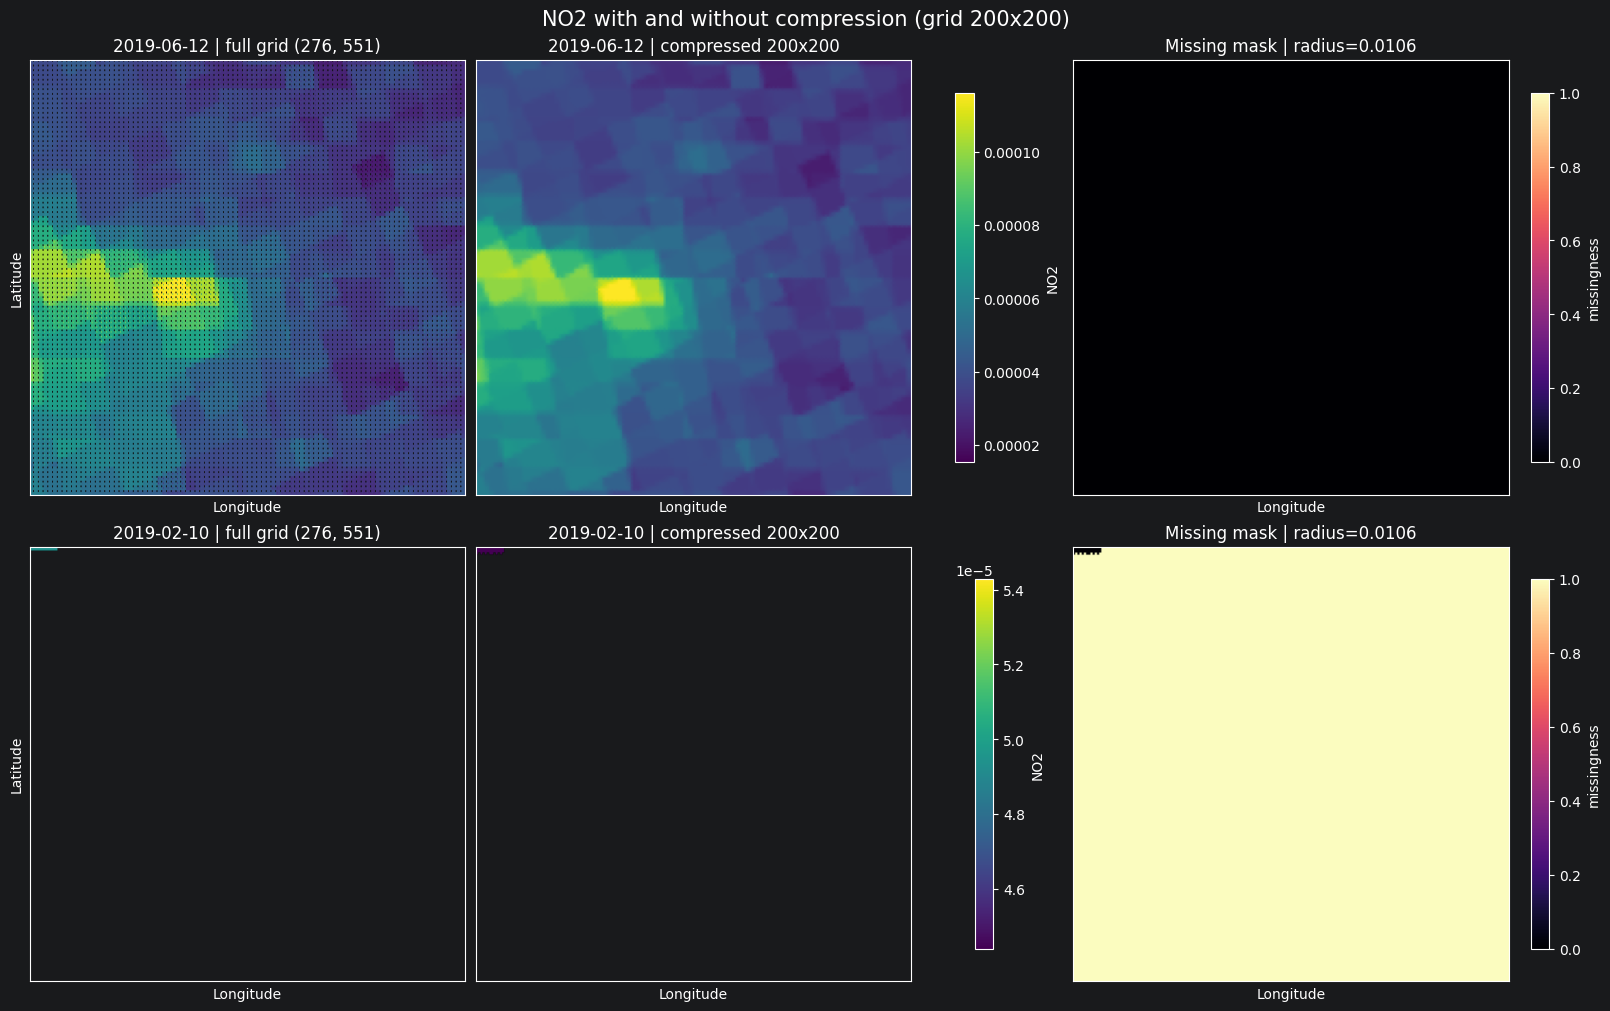

In [23]:
def plot_compression_examples(no2_df, grid_shape=(100,100), n_days=2, value_col="NO2", radius_multiplier=1.5):
    """Plot the same day with and without spatial compression using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    day_counts = work_df.groupby("day").size().sort_values(ascending=False)
    if day_counts.empty:
        raise ValueError("No valid days found for plotting.")

    if n_days <= 1:
        sample_days = pd.to_datetime([day_counts.index[0]])
    elif n_days == 2:
        sample_days = pd.to_datetime([day_counts.index[0], day_counts.index[-1]])
    else:
        sample_days = pd.to_datetime(day_counts.iloc[np.linspace(0, len(day_counts) - 1, n_days, dtype=int)].index.sort_values())
    full_extent = [lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()]

    fig, axes = plt.subplots(len(sample_days), 3, figsize=(16, 5 * len(sample_days)), constrained_layout=True)
    if len(sample_days) == 1:
        axes = np.array([axes])

    for row_idx, day in enumerate(sample_days):
        day_df = work_df.loc[work_df["day"] == day, ["latitude", "longitude", value_col]].dropna().copy()
        if day_df.empty:
            continue

        full_grid, full_mask, full_lat_axis, full_lon_axis, full_radius = build_radius_regular_grid(day_df, grid_shape=None, value_col=value_col, radius_multiplier=radius_multiplier)
        compressed_grid, compressed_mask, compressed_lat_axis, compressed_lon_axis, compressed_radius = build_radius_regular_grid(day_df, grid_shape=grid_shape, value_col=value_col, radius_multiplier=radius_multiplier)

        shared_vmin = np.nanmin([np.nanmin(full_grid), np.nanmin(compressed_grid)])
        shared_vmax = np.nanmax([np.nanmax(full_grid), np.nanmax(compressed_grid)])

        ax0, ax1, ax2 = axes[row_idx]
        im0 = ax0.imshow(full_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=full_extent)
        ax0.set_title(f"{day.date()} | full grid {full_grid.shape}")
        ax0.set_xlabel("Longitude")
        ax0.set_ylabel("Latitude")

        compressed_extent = [compressed_lon_axis.min(), compressed_lon_axis.max(), compressed_lat_axis.min(), compressed_lat_axis.max()]
        im1 = ax1.imshow(compressed_grid, origin="lower", aspect="auto", cmap="viridis", vmin=shared_vmin, vmax=shared_vmax, extent=compressed_extent)
        ax1.set_title(f"{day.date()} | compressed {grid_shape[0]}x{grid_shape[1]}")
        ax1.set_xlabel("Longitude")

        missing_mask = 1 - compressed_mask
        im2 = ax2.imshow(missing_mask, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=1, extent=compressed_extent)
        ax2.set_title(f"Missing mask | radius={compressed_radius:.4f}")
        ax2.set_xlabel("Longitude")

        for ax in (ax0, ax1, ax2):
            ax.set_yticks([])
            ax.set_xticks([])

        fig.colorbar(im0, ax=[ax0, ax1], shrink=0.85, label=value_col)
        fig.colorbar(im2, ax=ax2, shrink=0.85, label="missingness")

    fig.suptitle(f"NO2 with and without compression (grid {grid_shape[0]}x{grid_shape[1]})", fontsize=15)
    plt.show()


plot_compression_examples(no2, grid_shape=(200,200), n_days=2, value_col="NO2", radius_multiplier=1.5)

## Spatial Regularization

The NO₂ observations are irregularly distributed in space. To support convolution-based deep learning models, the data is transformed onto a regular spatial grid. This conversion allows each day to be represented as an image-like tensor.

In [24]:
def create_regularized_no2_dataset(no2_df, grid_shape=(100,100), value_col="NO2", min_points=20, radius_multiplier=1.5):
    """Create one compressed regular-grid NO2 frame per day using radius-based interpolation."""
    work_df = no2_df[["timestamp", "latitude", "longitude", value_col]].dropna().copy()
    work_df["day"] = pd.to_datetime(work_df["timestamp"], errors="coerce").dt.normalize()
    work_df = work_df.dropna(subset=["day"])

    if work_df.empty:
        raise ValueError("no2_df has no valid timestamp/latitude/longitude/value rows.")

    records = []
    grid_stack = []
    mask_stack = []
    day_groups = work_df.groupby("day", sort=True)

    for day, day_df in day_groups:
        if len(day_df) < min_points:
            # then skip that! `continue` skips this day, moves on to the next.
            continue

        compressed_grid, compressed_mask, lat_axis, lon_axis, radius = build_radius_regular_grid(
            day_df,
            grid_shape=grid_shape,
            value_col=value_col,
            radius_multiplier=radius_multiplier,
        )

        grid_stack.append(compressed_grid.astype(np.float32))
        mask_stack.append(compressed_mask.astype(np.uint8))
        records.append({
            "datetime": day,
            "n_observations": len(day_df),
            "grid": compressed_grid.astype(np.float32),
            "mask": compressed_mask.astype(np.uint8),
            "coverage_fraction": float(compressed_mask.mean()),
        })

    if not records:
        raise ValueError("No days had enough points to build a compressed dataset.")

    regularized_df = pd.DataFrame(records)
    grid_tensor = np.stack(grid_stack, axis=0)
    mask_tensor = np.stack(mask_stack, axis=0)

    return regularized_df, grid_tensor, mask_tensor, lat_axis, lon_axis


chosen_grid_shape = (100,100)
regularized_no2_df, regularized_no2_tensor, regularized_no2_mask_tensor, compressed_lat_axis, compressed_lon_axis = create_regularized_no2_dataset(
    no2,
    grid_shape=chosen_grid_shape,
    value_col="NO2",
    min_points=20,
    radius_multiplier=1.5,
)

print(f"Created compressed NO2 dataset with {len(regularized_no2_df):,} days.")
print(f"Grid tensor shape: {regularized_no2_tensor.shape}  (days, rows, cols)")
print(f"Mask tensor shape: {regularized_no2_mask_tensor.shape}")
print(f"Latitude axis length: {len(compressed_lat_axis)}")
print(f"Longitude axis length: {len(compressed_lon_axis)}")
print(regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].head())

np.savez_compressed(
    "./data/no2_regularized_100x100.npz",
    datetime=regularized_no2_df["datetime"].dt.strftime("%Y-%m-%d").to_numpy(),
    n_observations=regularized_no2_df["n_observations"].to_numpy(),
    coverage_fraction=regularized_no2_df["coverage_fraction"].to_numpy(),
    grids=regularized_no2_tensor,
    masks=regularized_no2_mask_tensor,
    lat_axis=compressed_lat_axis,
    lon_axis=compressed_lon_axis,
    grid_shape=np.array(chosen_grid_shape, dtype=np.int32),
)

metadata_df = regularized_no2_df[["datetime", "n_observations", "coverage_fraction"]].copy()
metadata_df["lat_axis"] = None
metadata_df["lon_axis"] = None
# metadata_df["lat_axis"][0] = [compressed_lat_axis.tolist()] * len(metadata_df)
# metadata_df["lon_axis"][0] = [compressed_lon_axis.tolist()] * len(metadata_df)

metadata_df["lat_axis"] = [compressed_lat_axis.tolist()] * len(metadata_df)
metadata_df["lon_axis"] = [compressed_lon_axis.tolist()] * len(metadata_df)

metadata_df.to_csv("./data/no2_regularized_100x100_metadata.csv", index=False)

regularized_no2_df.head()


Created compressed NO2 dataset with 338 days.
Grid tensor shape: (338, 100, 100)  (days, rows, cols)
Mask tensor shape: (338, 100, 100)
Latitude axis length: 100
Longitude axis length: 100
    datetime  n_observations  coverage_fraction
0 2019-01-01            8464             1.0000
1 2019-01-02            4479             0.5749
2 2019-01-03           13007             0.9713
3 2019-01-05            8464             1.0000
4 2019-01-06            4452             0.5982


,datetime,n_observations,grid,mask,coverage_fraction
0,2019-01-01,8464,"[[0.000102101694, 8.558364e-05, 7.44714e-05, 6...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.0000
1,2019-01-02,4479,"[[4.2139814e-05, 3.654661e-05, 3.613784e-05, 3...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.5749
2,2019-01-03,13007,"[[5.6902794e-05, 6.243599e-05, 6.2603074e-05, ...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",0.9713
3,2019-01-05,8464,"[[5.1588722e-05, 5.4509193e-05, 5.6152177e-05,...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...",1.0000
4,2019-01-06,4452,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",0.5982


Now that the NO2 data is on a regular grid, we can model each day as a 2D image.
The basic setup is:

1. Stack the previous 7 days as input channels.
2. Keep the missing-value masks as extra channels.
3. Predict the next day's NO2 grid.
4. Compute loss only on cells where the target mask is valid.

## Make train-test split more fairly.
- Currently we're chopping off temporally sorted data.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

regularized_path = Path("./data/no2_regularized_100x100.npz")
if not regularized_path.exists():
    raise FileNotFoundError(f"Could not find {regularized_path}. Run the regularization cell first.")

with np.load(regularized_path, allow_pickle=True) as data:
    regularized_no2_tensor = data["grids"].astype(np.float32)
    regularized_no2_mask_tensor = data["masks"].astype(np.float32)
    regularized_dates = pd.to_datetime(data["datetime"])
    compressed_lat_axis = data["lat_axis"].astype(np.float32)
    compressed_lon_axis = data["lon_axis"].astype(np.float32)

print("Grid tensor shape:", regularized_no2_tensor.shape)
print("Mask tensor shape:", regularized_no2_mask_tensor.shape)
print("Date range:", regularized_dates.min(), "->", regularized_dates.max())
print("Latitude axis length:", len(compressed_lat_axis))
print("Longitude axis length:", len(compressed_lon_axis))


def masked_mean_std(grids, masks):
    observed_values = grids[masks > 0]
    if observed_values.size == 0:
        raise ValueError("No observed values found while computing normalization stats.")

    mean = float(observed_values.mean())
    std = float(observed_values.std())
    if std < 1e-6:
        std = 1.0
    return mean, std


def normalize_grid(grid, mean, std):
    normalized = (grid - mean) / std
    return np.nan_to_num(normalized, nan=0.0).astype(np.float32)


lookback = 7
num_days = len(regularized_no2_tensor)
if num_days <= lookback:
    raise ValueError(f"Need more than {lookback} daily grids to build temporal samples.")

train_fraction = 0.7
val_fraction = 0.15
train_end = max(lookback + 1, int(num_days * train_fraction))
val_end = max(train_end + 1, int(num_days * (train_fraction + val_fraction)))
val_end = min(val_end, num_days - 1)

train_mean, train_std = masked_mean_std(
    regularized_no2_tensor[:train_end],
    regularized_no2_mask_tensor[:train_end],
)
print(f"Training normalization mean: {train_mean:.4f}")
print(f"Training normalization std:  {train_std:.4f}")


class NO2TemporalGridDataset(Dataset):
    def __init__(self, grids, masks, dates, lookback, mean, std, target_indices):
        self.grids = grids
        self.masks = masks
        self.dates = pd.to_datetime(dates)
        self.lookback = lookback
        self.mean = mean
        self.std = std
        self.target_indices = np.asarray(target_indices, dtype=np.int64)

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, item):
        target_idx = int(self.target_indices[item])
        input_grids = self.grids[target_idx - self.lookback:target_idx]
        input_masks = self.masks[target_idx - self.lookback:target_idx]
        target_grid = self.grids[target_idx]
        target_mask = self.masks[target_idx]

        input_grids = normalize_grid(input_grids, self.mean, self.std)
        target_grid = normalize_grid(target_grid, self.mean, self.std)

        x = np.concatenate([input_grids, input_masks], axis=0).astype(np.float32)
        y = target_grid[np.newaxis, ...].astype(np.float32)
        y_mask = target_mask[np.newaxis, ...].astype(np.float32)

        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(y_mask)


all_target_indices = np.arange(lookback, num_days)
train_target_indices = all_target_indices[all_target_indices < train_end]
val_target_indices = all_target_indices[(all_target_indices >= train_end) & (all_target_indices < val_end)]
test_target_indices = all_target_indices[all_target_indices >= val_end]

train_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    train_target_indices,
)
val_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    val_target_indices,
)
test_dataset = NO2TemporalGridDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    test_target_indices,
)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")

Using device: cpu
Grid tensor shape: (338, 100, 100)
Mask tensor shape: (338, 100, 100)
Date range: 2019-01-01 00:00:00 -> 2019-12-31 00:00:00
Latitude axis length: 100
Longitude axis length: 100
Training normalization mean: 0.0001
Training normalization std:  0.0001
Train samples: 229
Validation samples: 51
Test samples: 51


## CNN-Based Forecasting

The next section implements a convolutional neural network that predicts future NO₂ concentration fields from historical spatial grids.

# Mask-aware CNN on the regularized NO2 grids

Now that the data lives on a regular lattice, the next step is to treat each day like an image. The model will see two channels per historical day: standardized NO2 values and a binary mask that marks which cells were observed. The loss is masked as well, so only observed target cells contribute to training.

In [26]:
class MaskAwareCNN(nn.Module):
    def __init__(self, in_channels, hidden_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 2),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(hidden_channels // 2, 1, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)


def masked_mse(prediction, target, target_mask, eps=1e-6):
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


model = MaskAwareCNN(in_channels=lookback * 2).to(device)
print(model)

MaskAwareCNN(
  (encoder): Sequential(
    (0): Conv2d(14, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (head): Conv2d(32, 1, kernel_size=(1, 1), stride=(1, 1))
)


In [27]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_masked_mae = 0.0
    total_masked_points = 0.0

    for x, y, y_mask in loader:
        x = x.to(device)
        y = y.to(device)
        y_mask = y_mask.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        prediction = model(x)
        loss = masked_mse(prediction, y, y_mask)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        with torch.no_grad():
            masked_abs_error = (prediction - y).abs() * y_mask
            batch_masked_points = y_mask.sum().item()
            total_loss += loss.item() * max(batch_masked_points, 1.0)
            total_masked_mae += masked_abs_error.sum().item()
            total_masked_points += batch_masked_points

    mean_loss = total_loss / max(total_masked_points, 1.0)
    mean_mae = total_masked_mae / max(total_masked_points, 1.0)
    return mean_loss, mean_mae


torch.manual_seed(42)
np.random.seed(42)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

best_val_loss = float("inf")
best_state = None
history = []
num_epochs = 15

for epoch in range(1, num_epochs + 1):
    train_loss, train_mae = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_mae = run_epoch(model, val_loader)
    scheduler.step(val_loss)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_mae": train_mae,
            "val_loss": val_loss,
            "val_mae": val_mae,
        }
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | train mae {train_mae:.4f} | "
        f"val loss {val_loss:.4f} | val mae {val_mae:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train loss 0.7260 | train mae 0.4917 | val loss 0.2272 | val mae 0.2990
Epoch 02 | train loss 0.6136 | train mae 0.4334 | val loss 0.2133 | val mae 0.2989
Epoch 03 | train loss 0.6057 | train mae 0.4275 | val loss 0.2120 | val mae 0.2764
Epoch 04 | train loss 0.6079 | train mae 0.4200 | val loss 0.2068 | val mae 0.2688
Epoch 05 | train loss 0.5917 | train mae 0.4181 | val loss 0.2056 | val mae 0.2793
Epoch 06 | train loss 0.5945 | train mae 0.4150 | val loss 0.2023 | val mae 0.2733
Epoch 07 | train loss 0.5942 | train mae 0.4241 | val loss 0.2131 | val mae 0.2795
Epoch 08 | train loss 0.5788 | train mae 0.4255 | val loss 0.1972 | val mae 0.2677
Epoch 09 | train loss 0.5839 | train mae 0.4134 | val loss 0.2040 | val mae 0.2623
Epoch 10 | train loss 0.5696 | train mae 0.4079 | val loss 0.2123 | val mae 0.2698
Epoch 11 | train loss 0.5678 | train mae 0.4063 | val loss 0.1982 | val mae 0.2657
Epoch 12 | train loss 0.5816 | train mae 0.4134 | val loss 0.2170 | val mae 0.2863
Epoc

,epoch,train_loss,train_mae,val_loss,val_mae
0,1,0.726036,0.491694,0.227182,0.298977
1,2,0.613595,0.433402,0.213312,0.298873
2,3,0.605719,0.427532,0.211961,0.276364
3,4,0.607916,0.420042,0.206762,0.268810
4,5,0.591702,0.418122,0.205645,0.279273
5,6,0.594460,0.414994,0.202336,0.273254
6,7,0.594151,0.424063,0.213053,0.279512
7,8,0.578801,0.425455,0.197188,0.267671
8,9,0.583910,0.413376,0.204013,0.262276
9,10,0.569570,0.407922,0.212300,0.269778


Test MAE:  0.0000
Test RMSE: 0.0001


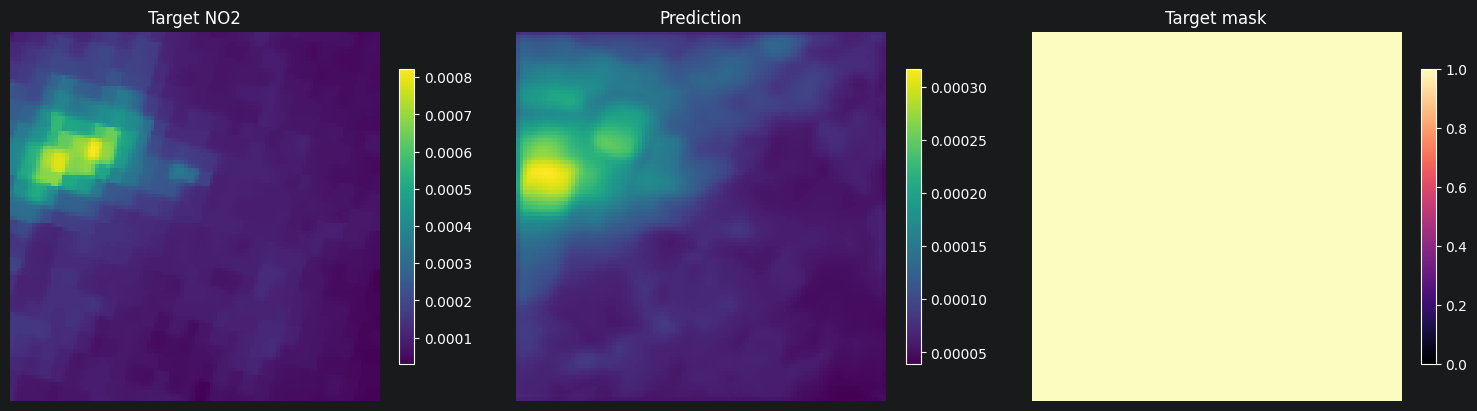

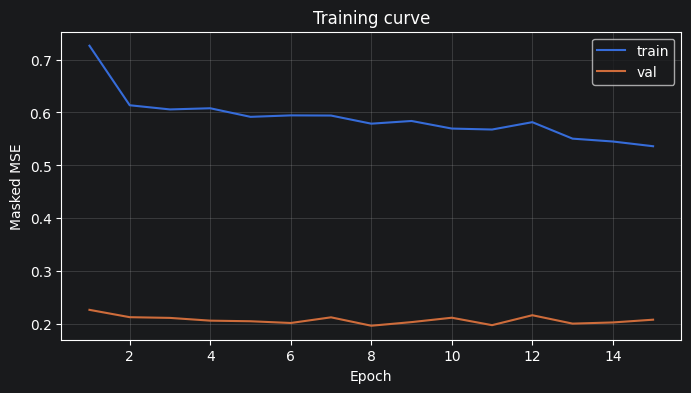

In [28]:
from random import randint
def evaluate_on_loader(model, loader, mean, std):
    model.eval()
    preds = []
    targets = []
    masks = []

    with torch.no_grad():
        for x, y, y_mask in loader:
            x = x.to(device)
            y = y.to(device)
            y_mask = y_mask.to(device)
            prediction = model(x)

            preds.append(prediction.cpu().numpy())
            targets.append(y.cpu().numpy())
            masks.append(y_mask.cpu().numpy())

    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    masks = np.concatenate(masks, axis=0)

    preds = preds * std + mean
    targets = targets * std + mean

    valid = masks > 0
    mae = np.mean(np.abs(preds[valid] - targets[valid]))
    rmse = np.sqrt(np.mean((preds[valid] - targets[valid]) ** 2))
    return preds, targets, masks, mae, rmse


preds, targets, masks, test_mae, test_rmse = evaluate_on_loader(model, test_loader, train_std, train_mean)
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

sample_index = randint(0, len(test_dataset))
sample_x, sample_y, sample_mask = test_dataset[sample_index]
with torch.no_grad():
    sample_pred = model(sample_x.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

sample_target = sample_y.squeeze(0) * train_std + train_mean
sample_prediction = sample_pred * train_std + train_mean
sample_mask_2d = sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("Prediction")
axes[1].axis("off")

im2 = axes[2].imshow(sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("Training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## ConvLSTM Forecasting

ConvLSTM models combine convolutional operations with recurrent temporal memory. They are designed to capture both spatial and temporal dynamics in sequential environmental data.

# ConvLSTM
The ConvLSTM architecture is designed to capture spatiotemporal dependencies in data. ConvLSTM especially captures the temporal evolution of spatial patterns, which is crucial for our task of predicting NO2 levels based on historical data. 


In [29]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn


class NO2TemporalSequenceDataset(Dataset):
    def __init__(self, grids, masks, dates, lookback, mean, std, target_indices):
        self.grids = grids
        self.masks = masks
        self.dates = dates
        self.lookback = lookback
        self.mean = mean
        self.std = std
        self.target_indices = target_indices

    def __len__(self):
        return len(self.target_indices)

    def __getitem__(self, idx):
        target_idx = self.target_indices[idx]
        start_idx = target_idx - self.lookback

        input_grids = np.nan_to_num(self.grids[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_masks = np.nan_to_num(self.masks[start_idx:target_idx], nan=0.0).astype(np.float32)
        input_seq = np.stack([input_grids, input_masks], axis=1).astype(np.float32)

        if self.mean is not None and self.std is not None:
            input_seq[:, 0] = (input_seq[:, 0] - self.mean) / self.std

        target = np.nan_to_num(self.grids[target_idx][None, ...], nan=0.0).astype(np.float32)
        target_mask = np.nan_to_num(self.masks[target_idx][None, ...], nan=0.0).astype(np.float32)

        if self.mean is not None and self.std is not None:
            target = (target - self.mean) / self.std

        return (
            torch.from_numpy(input_seq),
            torch.from_numpy(target),
            torch.from_numpy(target_mask),
        )


convlstm_train_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    train_target_indices,
)
convlstm_val_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    val_target_indices,
)
convlstm_test_dataset = NO2TemporalSequenceDataset(
    regularized_no2_tensor,
    regularized_no2_mask_tensor,
    regularized_dates,
    lookback,
    train_mean,
    train_std,
    test_target_indices,
)

convlstm_train_loader = DataLoader(convlstm_train_dataset, batch_size=batch_size, shuffle=True)
convlstm_val_loader = DataLoader(convlstm_val_dataset, batch_size=batch_size, shuffle=False)
convlstm_test_loader = DataLoader(convlstm_test_dataset, batch_size=batch_size, shuffle=False)


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.gates = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, state):
        h_prev, c_prev = state
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.gates(combined)
        input_gate, forget_gate, output_gate, candidate_gate = torch.chunk(gates, 4, dim=1)
        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        candidate_gate = torch.tanh(candidate_gate)
        c_next = forget_gate * c_prev + input_gate * candidate_gate
        h_next = output_gate * torch.tanh(c_next)
        return h_next, c_next


class MaskAwareConvLSTM(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ConvLSTMCell(input_dim=input_dim, hidden_dim=hidden_dim, kernel_size=kernel_size)
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim // 2, 1, kernel_size=1),
        )

    def forward(self, x):
        if x.ndim != 5:
            raise ValueError("Expected input of shape [batch, time, channels, height, width].")

        batch_size, time_steps, _, height, width = x.shape
        h_state = torch.zeros(batch_size, self.hidden_dim, height, width, device=x.device, dtype=x.dtype)
        c_state = torch.zeros_like(h_state)

        for time_index in range(time_steps):
            h_state, c_state = self.cell(x[:, time_index], (h_state, c_state))

        return self.decoder(h_state)


convlstm_model = MaskAwareConvLSTM(input_dim=2, hidden_dim=32).to(device)
print(convlstm_model)

convlstm_sample_seq, convlstm_sample_target, convlstm_sample_mask = convlstm_train_dataset[0]
print("ConvLSTM sample shapes:", convlstm_sample_seq.shape, convlstm_sample_target.shape, convlstm_sample_mask.shape)

MaskAwareConvLSTM(
  (cell): ConvLSTMCell(
    (gates): Conv2d(34, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (decoder): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  )
)
ConvLSTM sample shapes: torch.Size([7, 2, 100, 100]) torch.Size([1, 100, 100]) torch.Size([1, 100, 100])


In [30]:
from random import randint


def masked_mse(prediction, target, target_mask, eps=1e-6):
    prediction = torch.nan_to_num(prediction)
    target = torch.nan_to_num(target)
    squared_error = (prediction - target) ** 2 * target_mask
    return squared_error.sum() / target_mask.sum().clamp_min(eps)


torch.manual_seed(42)
np.random.seed(42)

convlstm_optimizer = torch.optim.AdamW(convlstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
convlstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    convlstm_optimizer,
    mode="min",
    patience=3,
    factor=0.5,
)

convlstm_best_val_loss = float("inf")
convlstm_best_state = None
convlstm_history = []
convlstm_num_epochs = 3

for epoch in range(1, convlstm_num_epochs + 1):
    convlstm_train_loss, convlstm_train_mae = run_epoch(
        convlstm_model,
        convlstm_train_loader,
        optimizer=convlstm_optimizer,
    )
    convlstm_val_loss, convlstm_val_mae = run_epoch(convlstm_model, convlstm_val_loader)
    convlstm_scheduler.step(convlstm_val_loss)

    convlstm_history.append(
        {
            "epoch": epoch,
            "train_loss": convlstm_train_loss,
            "train_mae": convlstm_train_mae,
            "val_loss": convlstm_val_loss,
            "val_mae": convlstm_val_mae,
        }
    )

    if convlstm_val_loss < convlstm_best_val_loss:
        convlstm_best_val_loss = convlstm_val_loss
        convlstm_best_state = {key: value.detach().cpu().clone() for key, value in convlstm_model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {convlstm_train_loss:.4f} | train mae {convlstm_train_mae:.4f} | "
        f"val loss {convlstm_val_loss:.4f} | val mae {convlstm_val_mae:.4f}"
    )



Epoch 01 | train loss 0.7173 | train mae 0.5236 | val loss 0.3917 | val mae 0.5045
Epoch 02 | train loss 0.6328 | train mae 0.4462 | val loss 0.2479 | val mae 0.3603
Epoch 03 | train loss 0.6210 | train mae 0.4300 | val loss 0.2027 | val mae 0.2617


ConvLSTM Test MAE:  0.0000
ConvLSTM Test RMSE: 0.0001


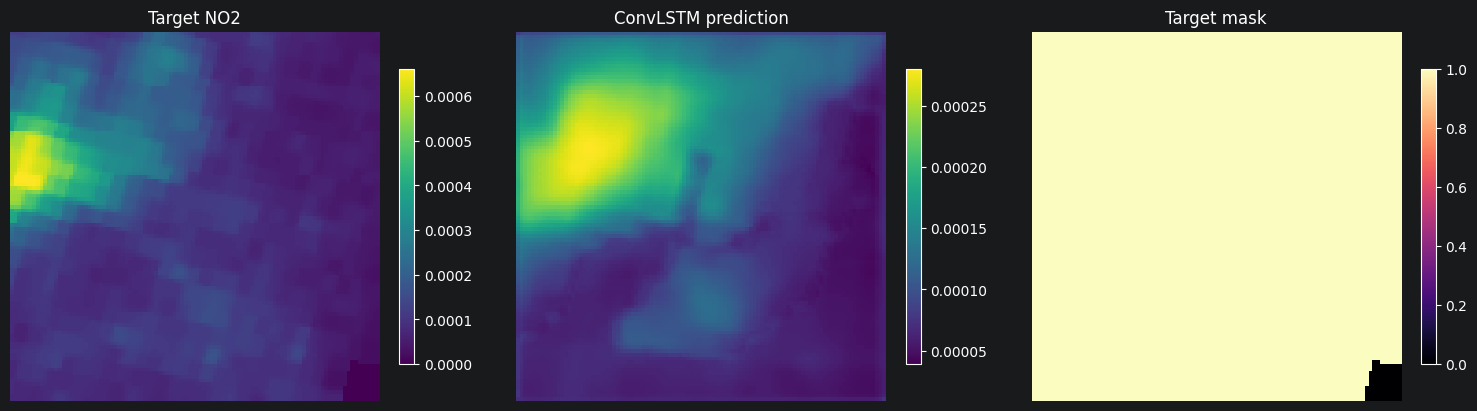

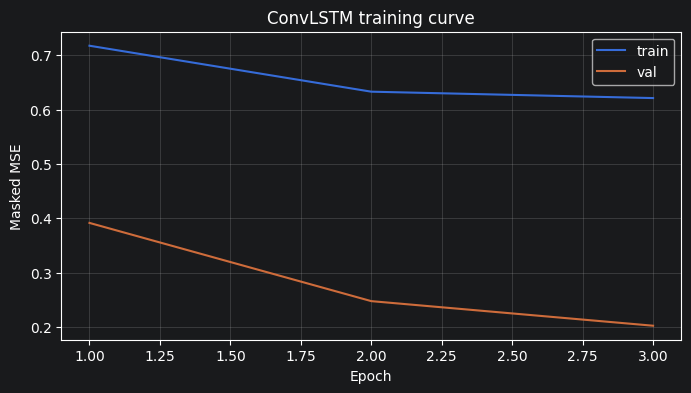

In [31]:
if convlstm_best_state is not None:
    convlstm_model.load_state_dict(convlstm_best_state)

convlstm_history_df = pd.DataFrame(convlstm_history)
convlstm_history_df

convlstm_preds, convlstm_targets, convlstm_masks, convlstm_test_mae, convlstm_test_rmse = evaluate_on_loader(
    convlstm_model,
    convlstm_test_loader,
    train_mean,
    train_std,
)
print(f"ConvLSTM Test MAE:  {convlstm_test_mae:.4f}")
print(f"ConvLSTM Test RMSE: {convlstm_test_rmse:.4f}")

convlstm_sample_index = randint(0, len(convlstm_test_dataset) - 1)
convlstm_sample_seq, convlstm_sample_target, convlstm_sample_mask = convlstm_test_dataset[convlstm_sample_index]
with torch.no_grad():
    convlstm_sample_pred = convlstm_model(convlstm_sample_seq.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

convlstm_sample_target = convlstm_sample_target.squeeze(0) * train_std + train_mean
convlstm_sample_prediction = convlstm_sample_pred * train_std + train_mean
convlstm_sample_mask_2d = convlstm_sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(convlstm_sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(convlstm_sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("ConvLSTM prediction")
axes[1].axis("off")

im2 = axes[2].imshow(convlstm_sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not convlstm_history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["train_loss"], label="train")
    plt.plot(convlstm_history_df["epoch"], convlstm_history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("ConvLSTM training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

torch.save(convlstm_model.state_dict(), f"{MODEL_DIR}/convlstm_model.pt")

## UNet Encoder-Decoder Model

The final architecture explored is a UNet-style encoder-decoder network. The encoder extracts multi-scale spatial features while the decoder reconstructs high-resolution predictions.

# Unet Encoder-Decoder

We can also try a UNet-style encoder-decoder architecture, which is effective for image-to-image tasks. The encoder captures spatial features at multiple scales, while the decoder reconstructs the output grid. Skip connections help preserve spatial details, which is important for accurate NO2 predictions.

In [32]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip_connection):
        x = self.up(x)
        height_diff = skip_connection.size(2) - x.size(2)
        width_diff = skip_connection.size(3) - x.size(3)

        x = nn.functional.pad(
            x,
            [
                width_diff // 2,
                width_diff - width_diff // 2,
                height_diff // 2,
                height_diff - height_diff // 2,
            ],
        )
        x = torch.cat([skip_connection, x], dim=1)
        return self.conv(x)


class MaskAwareUNet(nn.Module):
    def __init__(self, in_channels, base_channels=32):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = DownBlock(base_channels, base_channels * 2)
        self.down2 = DownBlock(base_channels * 2, base_channels * 4)
        self.down3 = DownBlock(base_channels * 4, base_channels * 8)
        self.bottleneck = DownBlock(base_channels * 8, base_channels * 16)
        self.up1 = UpBlock(base_channels * 16, base_channels * 8)
        self.up2 = UpBlock(base_channels * 8, base_channels * 4)
        self.up3 = UpBlock(base_channels * 4, base_channels * 2)
        self.up4 = UpBlock(base_channels * 2, base_channels)
        self.outc = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)


unet_model = MaskAwareUNet(in_channels=lookback * 2, base_channels=32).to(device)
print(unet_model)

unet_optimizer = torch.optim.AdamW(unet_model.parameters(), lr=1e-3, weight_decay=1e-4)
unet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(unet_optimizer, mode="min", patience=3, factor=0.5)

unet_best_val_loss = float("inf")
unet_best_state = None
unet_history = []
unet_num_epochs = 10

for epoch in range(1, unet_num_epochs + 1):
    unet_train_loss, unet_train_mae = run_epoch(unet_model, train_loader, optimizer=unet_optimizer)
    unet_val_loss, unet_val_mae = run_epoch(unet_model, val_loader)
    unet_scheduler.step(unet_val_loss)

    unet_history.append(
        {
            "epoch": epoch,
            "train_loss": unet_train_loss,
            "train_mae": unet_train_mae,
            "val_loss": unet_val_loss,
            "val_mae": unet_val_mae,
        }
    )

    if unet_val_loss < unet_best_val_loss:
        unet_best_val_loss = unet_val_loss
        unet_best_state = {key: value.detach().cpu().clone() for key, value in unet_model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {unet_train_loss:.4f} | train mae {unet_train_mae:.4f} | "
        f"val loss {unet_val_loss:.4f} | val mae {unet_val_mae:.4f}"
    )

if unet_best_state is not None:
    unet_model.load_state_dict(unet_best_state)

unet_history_df = pd.DataFrame(unet_history)
unet_history_df

unet_preds, unet_targets, unet_masks, unet_test_mae, unet_test_rmse = evaluate_on_loader(
    unet_model,
    test_loader,
    train_std,
    train_mean,
)
print(f"UNet Test MAE:  {unet_test_mae:.4f}")
print(f"UNet Test RMSE: {unet_test_rmse:.4f}")


MaskAwareUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(14, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): DownBlock(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [33]:
# comparison_df = pd.DataFrame({
#     "Model": [
#         "Persistence",
#         "XGBoost",
#         "CNN",
#         "ConvLSTM",
#         "UNet"
#     ],
#     "MAE": [
#         persistence_mae,
#         xgb_mae,
#         cnn_mae,
#         convlstm_mae,
#         unet_mae
#     ],
#     "RMSE": [
#         persistence_rmse,
#         xgb_rmse,
#         cnn_rmse,
#         convlstm_rmse,
#         unet_rmse
#     ]
# })
#
# comparison_df.sort_values("RMSE")

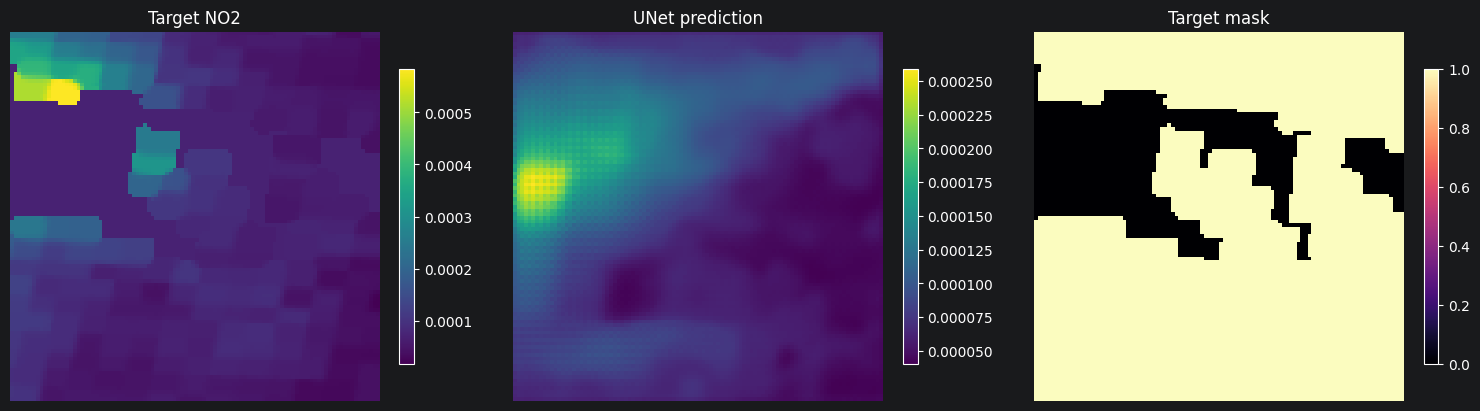

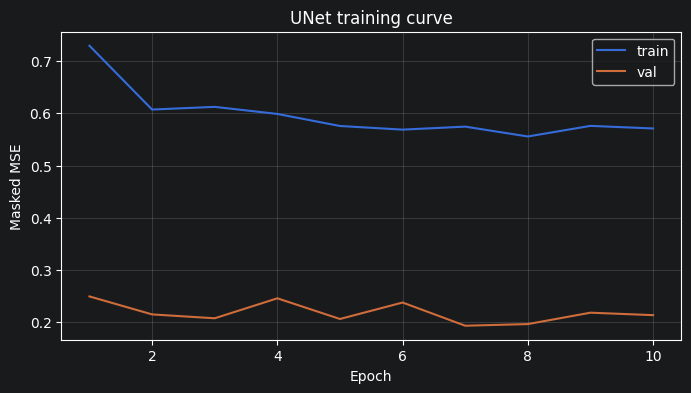

In [34]:
torch.save(model.state_dict(), f"{MODEL_DIR}/unet_model.pt")


unet_sample_index = randint(0, len(test_dataset) - 1)
unet_sample_x, unet_sample_y, unet_sample_mask = test_dataset[unet_sample_index]
with torch.no_grad():
    unet_sample_pred = unet_model(unet_sample_x.unsqueeze(0).to(device)).cpu().squeeze(0).squeeze(0)

unet_sample_target = unet_sample_y.squeeze(0) * train_std + train_mean
unet_sample_prediction = unet_sample_pred * train_std + train_mean
unet_sample_mask_2d = unet_sample_mask.squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(unet_sample_target.numpy(), cmap="viridis")
axes[0].set_title("Target NO2")
axes[0].axis("off")

im1 = axes[1].imshow(unet_sample_prediction.numpy(), cmap="viridis")
axes[1].set_title("UNet prediction")
axes[1].axis("off")

im2 = axes[2].imshow(unet_sample_mask_2d.numpy(), cmap="magma", vmin=0, vmax=1)
axes[2].set_title("Target mask")
axes[2].axis("off")

fig.colorbar(im0, ax=axes[0], shrink=0.8)
fig.colorbar(im1, ax=axes[1], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

if not unet_history_df.empty:
    plt.figure(figsize=(8, 4))
    plt.plot(unet_history_df["epoch"], unet_history_df["train_loss"], label="train")
    plt.plot(unet_history_df["epoch"], unet_history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Masked MSE")
    plt.title("UNet training curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()